<a href="https://colab.research.google.com/github/koh-hongQ/Understanding_AI_with_Math/blob/main/0924_VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

이번 숙제에서는 Variational AutoEncoder (VAE)를 직접 구현하고 MNIST 데이터셋을 대상으로 실행합니다.



1. VAE 모델 구현 및 학습:



  1-1.기본적인 Encoder–Decoder 구조를 갖춘 VAE를 구현하세요.


1-2.MNIST 데이터셋(tf.keras.datasets.mnist.load_data()로 불러오기)을 사용합니다. 보통 아래처럼 합니다.



In [4]:
import sys

# 코랩의 경우 깃허브 저장소로부터 utils.py와 vae_utils.py, download_kaggle_data.sh를 다운로드 합니다.
if 'google.colab' in sys.modules:
    !wget https://raw.githubusercontent.com/rickiepark/Generative_Deep_Learning_2nd_Edition/main/notebooks/utils.py
    !mkdir -p notebooks
    !mv utils.py notebooks
    !wget https://raw.githubusercontent.com/rickiepark/Generative_Deep_Learning_2nd_Edition/main/notebooks/03_vae/03_vae_faces/vae_utils.py
    !wget https://raw.githubusercontent.com/rickiepark/Generative_Deep_Learning_2nd_Edition/main/scripts/downloaders/download_kaggle_data.sh

--2025-09-24 13:16:08--  https://raw.githubusercontent.com/rickiepark/Generative_Deep_Learning_2nd_Edition/main/notebooks/utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 771 [text/plain]
Saving to: ‘utils.py’

utils.py            100%[===================>]     771  --.-KB/s    in 0s      

2025-09-24 13:16:08 (34.6 MB/s) - ‘utils.py’ saved [771/771]

--2025-09-24 13:16:08--  https://raw.githubusercontent.com/rickiepark/Generative_Deep_Learning_2nd_Edition/main/notebooks/03_vae/03_vae_faces/vae_utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaitin

In [80]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras import (
    layers,
    models,
    datasets,
    callbacks,
    utils,
    metrics,
    losses,
    optimizers,
)

from scipy.stats import norm
import pandas as pd

from notebooks.utils import sample_batch, display

from vae_utils import get_vector_from_label, add_vector_to_images, morph_faces
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


In [96]:
import tensorflow as tf



# 데이터불러오기

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()



# 스케일링 (0~255 → 0~1)

x_train = x_train.astype("float32") / 255.0

x_test = x_test.astype("float32") / 255.0

x_train = x_train[..., tf.newaxis]  # shape: (num_samples, 32, 32, 1)
x_test  = x_test[..., tf.newaxis]



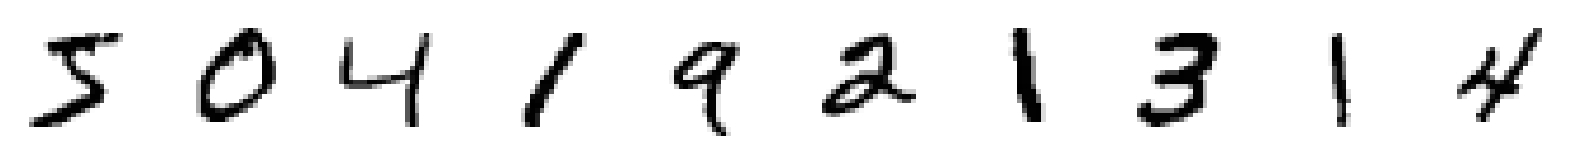

In [97]:
display(x_train)

In [120]:

BATCH_SIZE = 128
EPOCHS = 2
IMAGE_SIZE = 28
CHANNELS = 1
EMBEDDING_DIM = 50
BETA = 1.0  # KL loss weight

1-3. 모델 학습 후



In [99]:
# VAE에서는 z ~ N(z_mean, z_var)에서 샘플링을 해야 하는데, 그 과정을 이 레이어에서 처리합니다.
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = K.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


In [100]:
encoder_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
x = layers.Conv2D(32, (3,3), strides=2, activation="relu", padding="same")(encoder_input)  # 28->14
x = layers.Conv2D(64, (3,3), strides=2, activation="relu", padding="same")(x)            # 14->7
shape_before_flattening = K.int_shape(x)[1:]

x = layers.Flatten()(x)
z_mean = layers.Dense(EMBEDDING_DIM, name="z_mean")(x)
z_log_var = layers.Dense(EMBEDDING_DIM, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = models.Model(encoder_input, [z_mean, z_log_var, z], name="encoder")
encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer_12[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_28[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 3136)      │          0 │ conv2d_29[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 50)        │    156,850 │ flatten_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 50)        │    156,850 │ flatten_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_9          │ (None, 50)        │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 332,516 (1.27 MB)

 Trainable params: 332,516 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [101]:
decoder_input = layers.Input(shape=(EMBEDDING_DIM,))
x = layers.Dense(np.prod(shape_before_flattening))(decoder_input)
x = layers.Reshape(shape_before_flattening)(x)
x = layers.Conv2DTranspose(64, (3,3), strides=2, activation="relu", padding="same")(x)  # 7->14
x = layers.Conv2DTranspose(32, (3,3), strides=2, activation="relu", padding="same")(x)  # 14->28
decoder_output = layers.Conv2D(CHANNELS, (3,3), activation="sigmoid", padding="same")(x)

decoder = models.Model(decoder_input, decoder_output)
decoder.summary()


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3136)           │       159,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_9 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_22             │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_23             │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,617 (842.25 KB)

 Trainable params: 215,617 (842.25 KB)

 Non-trainable params: 0 (0.00 B)

In [104]:
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                losses.binary_crossentropy(data, reconstruction)
            )
            kl_loss = tf.reduce_mean(
                -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            total_loss = reconstruction_loss + BETA * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {m.name: m.result() for m in self.metrics}



In [105]:
# 변이형 오토인코더 컴파일
optimizer = optimizers.Adam(learning_rate=0.0005)
vae.compile(optimizer=optimizer)
# 변이형 오토인코더(VAE)에서는 손실 함수를 모델 클래스
# 내부에서 직접 정의했기 때문에 optimizer만 전달합니다.

In [122]:
history = vae.fit(
    x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test, x_test),
)

Epoch 1/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - kl_loss: 9.6946e-08 - reconstruction_loss: 0.2638 - total_loss: 0.2638

ValueError: No loss to compute. Provide a `loss` argument in `compile()`.

In [ ]:
# training &  loss 곡선 시각화
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# 최종 모델 저장
vae.save("./models/vae")
encoder.save("./models/encoder")
decoder.save("./models/decoder")

1-4. 재구성된 이미지



In [45]:
# 테스트셋의 일부를 선택합니다.
n_to_predict = 5000
example_images = x_test[:n_to_predict]
example_labels = y_test[:n_to_predict]

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step
실제


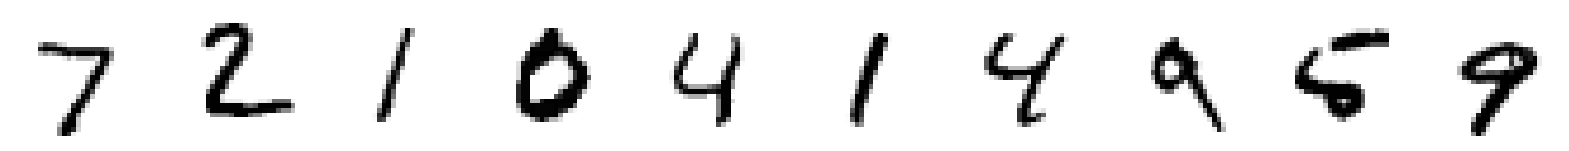

재구성 이미지


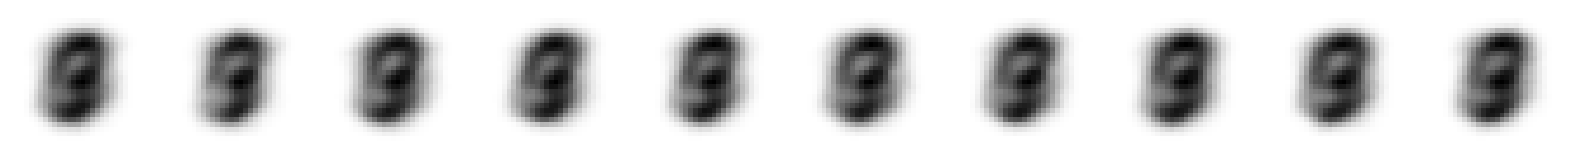

In [46]:
# 오토인코더 예측을 만들고 출력합니다.
z_mean, z_log_var, reconstructions = vae.predict(example_images)
print("실제")
display(example_images)
print("재구성 이미지")
display(reconstructions)

1-5. 잠재공간(latent space) 시각화를 하세요.

In [108]:
# 예제 이미지 인코딩
z_mean, z_var, z = encoder.predict(example_images)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [109]:
# 임베딩의 몇 가지 예
print(z[:10])

[[ 8.80740821e-01 -1.79690039e+00  1.61793780e+00  8.32765818e-01
  -5.08934617e-01 -9.72360730e-01  1.89703871e-02  1.08591819e+00
  -3.28364074e-01 -9.25076187e-01 -6.94017410e-01  1.00215875e-01
  -6.51989818e-01 -6.64128006e-01  5.00063300e-01  5.50519288e-01
  -7.30606616e-01 -4.58880842e-01 -6.85742199e-01  7.66251147e-01
   9.52981889e-01  4.19667326e-02  7.56464079e-02  1.16776451e-02
   1.25343335e+00  3.85466814e-02  6.77516043e-01  6.40824735e-01
  -1.49339825e-01 -2.14783406e+00  1.12772143e+00  3.04164499e-01
   1.10451722e+00  2.08019584e-01 -4.26993042e-01  5.37892342e-01
   5.51584363e-01 -1.91811514e+00 -1.13885748e+00 -1.08249760e+00
   1.04929674e+00  6.08923554e-01 -1.27913463e+00  9.59125280e-01
   6.64199889e-01 -5.50248682e-01  4.00004596e-01  9.35361147e-01
  -8.47278893e-01  1.08161397e-01]
 [-9.80276287e-01 -2.32403249e-01 -1.17504068e-01 -5.91488421e-01
  -1.39230037e+00 -1.18323696e+00 -2.25830343e-04 -2.81506330e-01
  -1.14377654e+00 -1.27006555e+00  7.4240

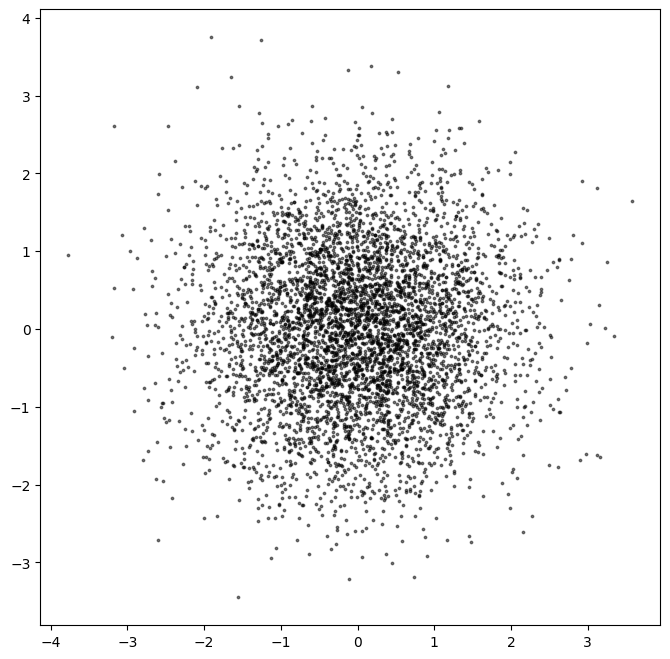

In [110]:
# 2D 공간에서 인코딩된 포인트 표시
figsize = 8

plt.figure(figsize=(figsize, figsize))
plt.scatter(z[:, 0], z[:, 1], c="black", alpha=0.5, s=3)
plt.show()

In [111]:
# 표준 정규 분포에서 잠재 공간의 일부 포인트를 샘플링합니다.
grid_width, grid_height = (6, 3)
z_sample = np.random.normal(size=(grid_width * grid_height, 2))

In [112]:
# 샘플링된 포인트 디코딩
reconstructions = decoder.predict(z_sample)

ValueError: Input 0 of layer "functional_8" is incompatible with the layer: expected shape=(None, 50), found shape=(18, 2)

In [113]:
# 원본 임베딩과 샘플링된 임베딩을 p값으로 변환하기
p = norm.cdf(z)
p_sample = norm.cdf(z_sample)

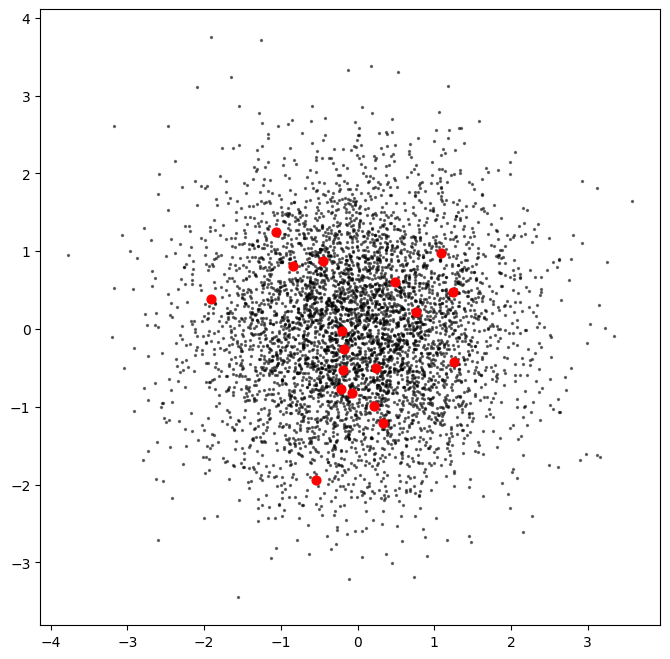

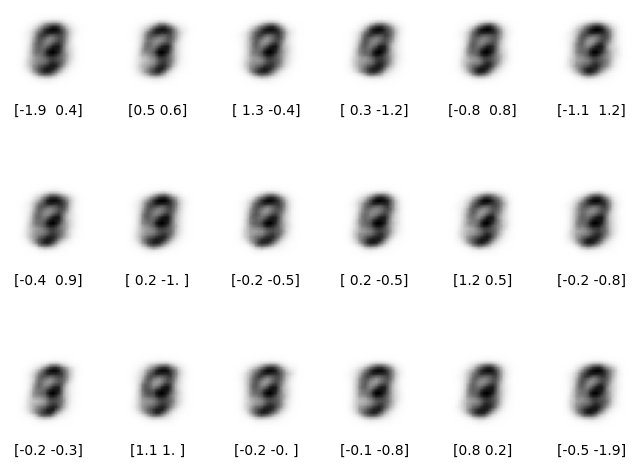

In [114]:

# 그래프를 그립니다....
figsize = 8
plt.figure(figsize=(figsize, figsize))

# ... 원본 임베딩 ...
plt.scatter(z[:, 0], z[:, 1], c="black", alpha=0.5, s=2)

# ... 잠재 공간에 새로 생성된 포인트
plt.scatter(z_sample[:, 0], z_sample[:, 1], c="red", alpha=1, s=40)
plt.show()

# 디코딩된 이미지 그리드를 추가합니다.
fig = plt.figure(figsize=(figsize, grid_height * 2))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

for i in range(grid_width * grid_height):
    ax = fig.add_subplot(grid_height, grid_width, i + 1)
    ax.axis("off")
    ax.text(
        0.5,
        -0.35,
        str(np.round(z_sample[i, :], 1)),
        fontsize=10,
        ha="center",
        transform=ax.transAxes,
    )
    ax.imshow(reconstructions[i, :, :], cmap="Greys")

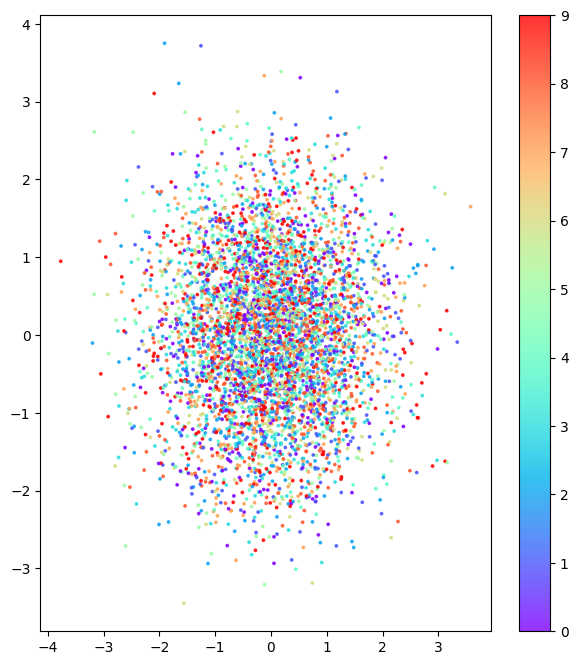

In [115]:
# 레이블에 따라 임베딩에 색상을 지정합니다.
figsize = 8
fig = plt.figure(figsize=(figsize * 2, figsize))
ax = fig.add_subplot(1, 2, 1)
plot_1 = ax.scatter(
    z[:, 0], z[:, 1], cmap="rainbow", c=example_labels, alpha=0.8, s=3
)
plt.colorbar(plot_1)

plt.show()

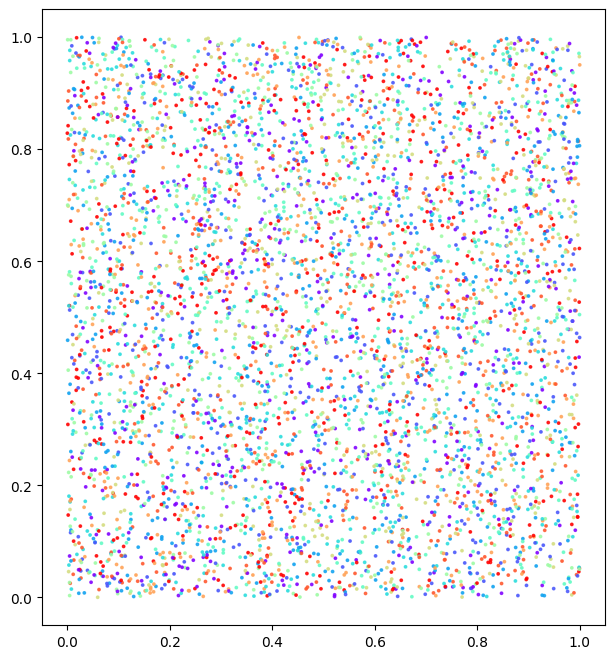

In [116]:
# 위에껄 p로 norm 할거일뿐
figsize = 8
fig = plt.figure(figsize=(figsize * 2, figsize))
ax = fig.add_subplot(1, 2, 2)
plot_2 = ax.scatter(
    p[:, 0], p[:, 1], cmap="rainbow", c=example_labels, alpha=0.8, s=3
)
plt.show()

ValueError: Input 0 of layer "functional_8" is incompatible with the layer: expected shape=(None, 50), found shape=(32, 2)

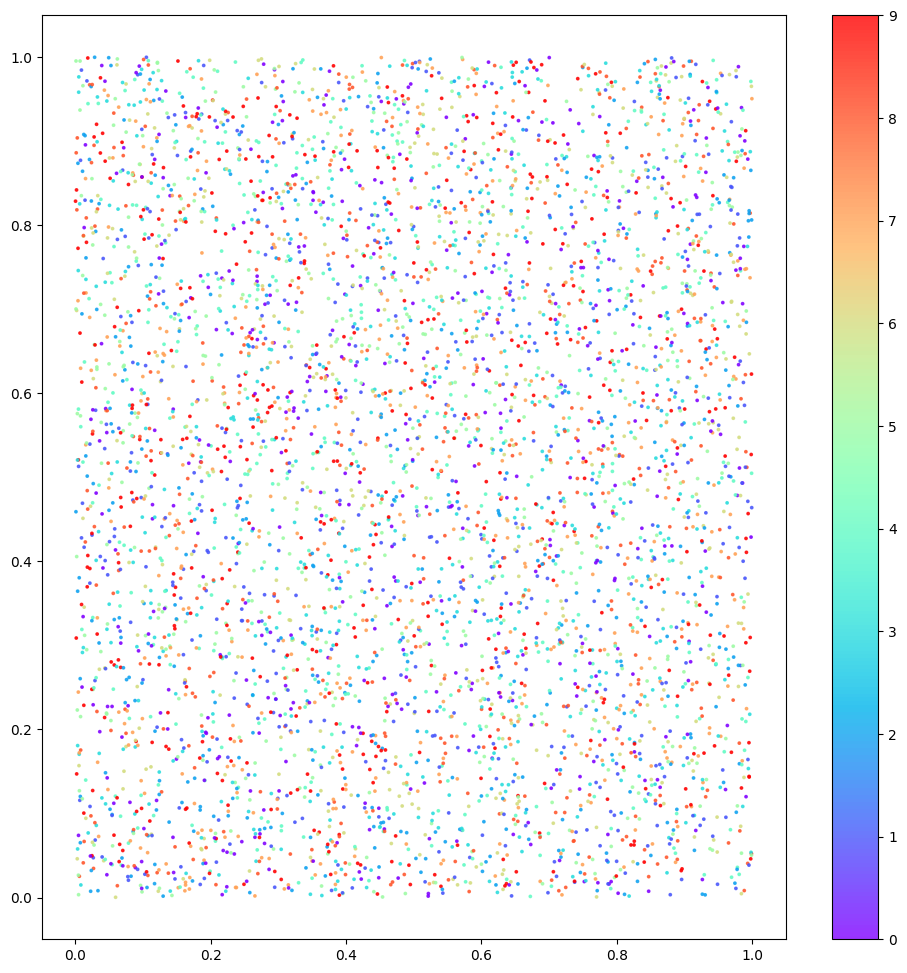

In [117]:
# 이것 역시 z를 p로 norm한걸 시각화
# 거기에 격자로 p 샘플 만들어서 그걸 decoder에 넣고 나온결과를 grid로 시각화
# 레이블(의류 종류)에 따라 임베딩에 색상을 지정합니다.
figsize = 12
grid_size = 15
plt.figure(figsize=(figsize, figsize))
plt.scatter(
    p[:, 0], p[:, 1], cmap="rainbow", c=example_labels, alpha=0.8, s=3
)
plt.colorbar()

x = norm.ppf(np.linspace(0, 1, grid_size))
y = norm.ppf(np.linspace(1, 0, grid_size))
xv, yv = np.meshgrid(x, y)
xv = xv.flatten()
yv = yv.flatten()
grid = np.array(list(zip(xv, yv)))

reconstructions = decoder.predict(grid)
plt.scatter(grid[:, 0], grid[:, 1], c="black", alpha=1, s=10)
plt.show()

fig = plt.figure(figsize=(figsize, figsize))
fig.subplots_adjust(hspace=0.4, wspace=0.4)
for i in range(grid_size**2):
    ax = fig.add_subplot(grid_size, grid_size, i + 1)
    ax.axis("off")
    ax.imshow(reconstructions[i, :, :], cmap="Greys")